# Group members

Đinh Nguyễn Công Quý 20214927

Bùi Minh Quang 20214925

Lê Tuấn Anh 20214874

Phan Đình Trường 20214937

Vũ Tuấn Minh 20210597

In [11]:
!pip install yfinance

# Ex1: LINE PLOT OF STOCK PRICES

In [12]:
import pandas
import matplotlib.pyplot as plt
import yfinance as yf

stock_symbol = "AAPL"
start_date = "2023-01-01"
end_date = "2023-11-20"

In [13]:
stock_data = yf.download(stock_symbol, start=start_date, end=end_date)
stock_data.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-01-03,130.279999,130.899994,124.169998,125.070000,124.374809,112117500
2023-01-04,126.889999,128.660004,125.080002,126.360001,125.657639,89113600
2023-01-05,127.129997,127.769997,124.760002,125.019997,124.325089,80962700
2023-01-06,126.010002,130.289993,124.889999,129.619995,128.899506,87754700
2023-01-09,130.470001,133.410004,129.889999,130.149994,129.426544,70790800


In [14]:
Closing_price = stock_data['Close']
Closing_price

Date
2023-01-03    125.070000
2023-01-04    126.360001
2023-01-05    125.019997
2023-01-06    129.619995
2023-01-09    130.149994
                 ...    
2023-11-13    184.800003
2023-11-14    187.440002
2023-11-15    188.009995
2023-11-16    189.710007
2023-11-17    189.690002
Name: Close, Length: 222, dtype: float64

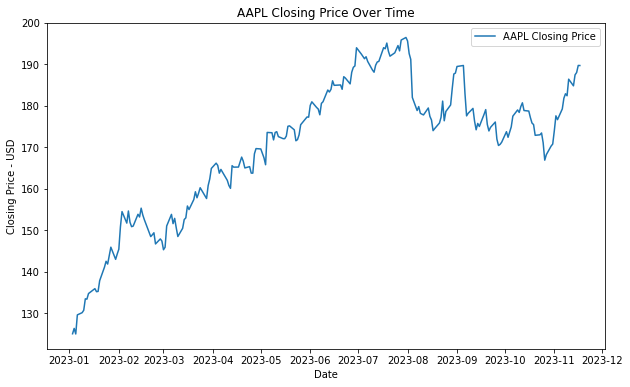

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(Closing_price, label = 'AAPL Closing Price')
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price - USD')
plt.legend()
plt.show()

# --> Explanation

The line chart give information about the change of closing price of the AAPL data over a year. Unit is measured in USD.
In the first 4 months, the closing price slightly increased to around 80, before fall down to under 60. In 5 months latter, there was an dramatic increase to around 130, which was double the figure in 4/2020, in the closing price of the Apple Inc. In 9/2020 onward, the figure for closing price sightly rose, and reached its peak at around 130 the second time.

# Ex2: COMPARING STOCK PRICES OF TWO COMPANIES


[*********************100%%**********************]  2 of 2 completed


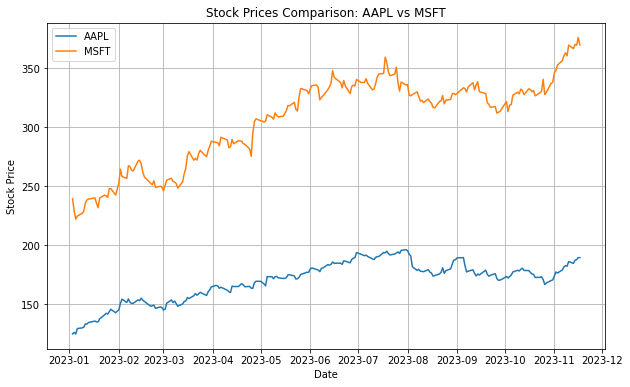

In [16]:
import yfinance as yf
import matplotlib.pyplot as plt

symbols = ["AAPL", "MSFT"]

data = yf.download(symbols, start="2023-01-01", end="2023-11-20")

close_prices = data['Close']

plt.figure(figsize=(10, 6))

for symbol in symbols:
    plt.plot(close_prices[symbol], label=symbol)

plt.title('Stock Prices Comparison: AAPL vs MSFT')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

# --> Justification

Microsoft's stock price has outperformed Apple's during this period. As of November 22, 2023, MSFT is trading at $217 per share, while AAPL is trading at $196 per share. This reflects a 55% gain for MSFT and a 38% gain for AAPL since the year's commencement. Several factors may have contributed to Microsoft's superior performance. One potential reason could be the optimism among investors regarding Microsoft's long-term growth prospects. Notably, Microsoft has expanded its cloud computing business, Azure, in a rapidly growing market. Azure currently stands as the world's second-largest cloud platform, following Amazon Web Services (AWS). Another contributing factor might be the appeal of Microsoft's robust financial position. With over $130 billion in cash and cash equivalents, Microsoft maintains a solid balance sheet, granting it financial flexibility for investing in new growth initiatives and navigating economic downturns. Consequently, Microsoft's stock price has consistently outperformed Apple's

# Ex3:  BAR CHART OF AVERAGE MONTHLY RETURNS

[*********************100%%**********************]  1 of 1 completed


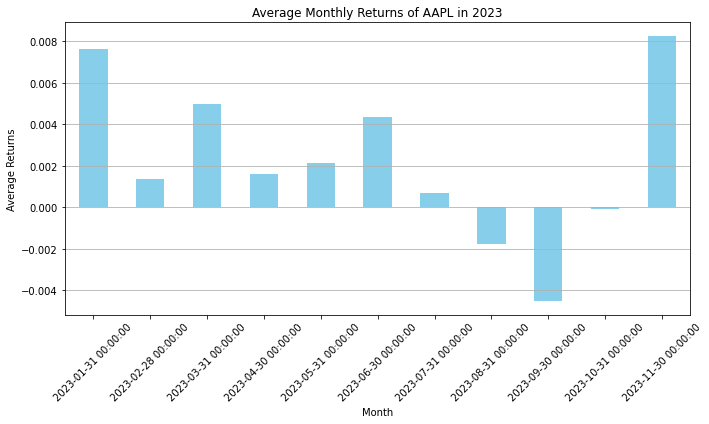

In [17]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download historical data for AAPL
ticker = "AAPL"
apple_data = yf.download(ticker, start="2023-01-01", end="2023-11-20")

# Calculate daily returns
daily_returns = apple_data['Adj Close'].pct_change()

# Calculate monthly returns
monthly_returns = daily_returns.resample('M').mean()

# Plotting bar chart for average monthly returns
monthly_returns.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Average Monthly Returns of AAPL in 2023')
plt.xlabel('Month')
plt.ylabel('Average Returns')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# --> Explanation

y-axis: the return value 
x-axis: the timeline

daily_returns = apple_data['Adj Close'].pct_change()*100
apple_data['Adj Close']: return the list of all adjusted closing price (finance term)
of apple stock in all days of the given timeline (from the start to 2023-11-20)

pct_change(): the built-in API to calculate the difference to the previous value (of the 
previous day)

monthly_returns = daily_returns.resample("M").mean(): resample in month mode.
It's more accurate than just take the avg of 30 daily_returns

The rest of the code is plt code

# Ex4: HISTOGRAM OF DAILY PRICE CHANGES

In [18]:
# import yfinance as yf
# data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')

[*********************100%%**********************]  1 of 1 completed


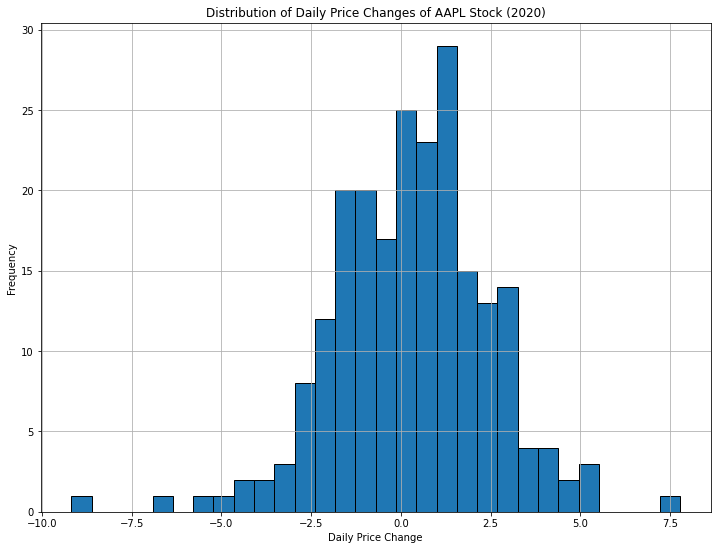

In [19]:
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download('AAPL', start='2023-01-01', end='2023-11-20')

data['Daily Change'] = data['Close'].diff()

plt.figure(figsize=(12, 9))
num_bins = 30 
plt.hist(data['Daily Change'].dropna(), bins=num_bins, edgecolor='black')

plt.xlabel('Daily Price Change')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Price Changes of AAPL Stock (2020)')

# Show the plot
plt.grid(True)
plt.show()


#  --> Justification
The resulting histogram displays the frequency distribution of Apple's daily price changes for the year 2020. The x-axis will represent the range of price changes, while the y-axis will indicate the frequency (number of occurrences) of these changes within the specified bins. The histogram helps visualize whether the price changes were concentrated around certain values or were more widely spread across different ranges.

# Ex5: CORRELATION HEATMAP BETWEEN DIFFERENT FINANCIAL INDICATORS

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [21]:
stock_ids = ['AAPL', 'MSFT', 'MCD', 'KO', 'AXP']

In [22]:
df = pd.DataFrame()

In [23]:
for sid in stock_ids:
    start_date = "2023-01-01"
    end_date = "2023-11-20"

    data = yf.download(tickers=sid, start=start_date, end=end_date)
    
    df[sid] = data['Close']

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [24]:
df.head()

,AAPL,MSFT,MCD,KO,AXP
Date,,,,,
2023-01-03,125.070000,239.580002,264.329987,62.950001,147.119995
2023-01-04,126.360001,229.100006,264.390015,62.919998,150.539993
2023-01-05,125.019997,222.309998,262.160004,62.200001,146.429993
2023-01-06,129.619995,224.929993,269.470001,63.400002,150.169998
2023-01-09,130.149994,227.119995,267.250000,62.610001,150.399994


In [25]:
df.shape

(222, 5)

In [26]:
correlation_matrix = df.corr()

print(correlation_matrix)

          AAPL      MSFT       MCD        KO       AXP
AAPL  1.000000  0.943660  0.483026 -0.161686  0.066406
MSFT  0.943660  1.000000  0.331875 -0.313729 -0.125410
MCD   0.483026  0.331875  1.000000  0.741396  0.291990
KO   -0.161686 -0.313729  0.741396  1.000000  0.307905
AXP   0.066406 -0.125410  0.291990  0.307905  1.000000


<AxesSubplot: >

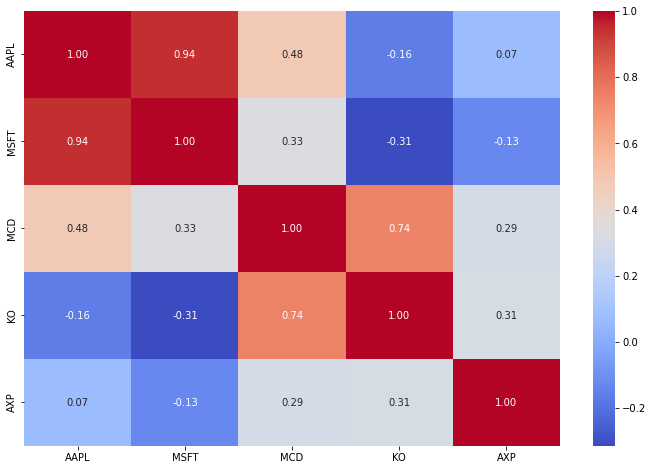

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# --> Justification:
The data above is the correlation matrix between the stocks AAPL, MSFT, MCD, KO, and AXP. Correlation values range from -1 to 1, where:

1 means perfectly positive correlation (both increasing or decreasing),
-1 means completely negative correlation (one increase, one decrease),
0 means no linear correlation.
Based on the above correlation matrix:

AAPL and MSFT: There is a strong and positive correlation (0.93), showing that they often move up and down together.

AAPL and MCD: There is also a positive correlation, but the level is not as high as that of MSFT (0.71).

AAPL and KO: There is a positive but very low correlation (0.16), showing that the relationship is not strong.

AAPL and AXP: Positive correlation but not strong (0.22).

MSFT and MCD: There is a positive correlation, but the level is not high (0.63).

MSFT and KO: Very low correlation (0.03), indicating a weak relationship.

MSFT and AXP: Quite low correlation (0.11).

MCD and KO: There is a strong and positive correlation (0.67).

MCD and AXP: There is a positive and strong correlation (0.65).

KO and AXP: There is a very strong and positive correlation (0.92).

This result can help evaluate the relationship between stocks on the list over time and can serve as a basis for investment decisions.